In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time



In [2]:
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

In [3]:
def rosenbrock_gradient(x, y):
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)

    return np.array([dx, dy])

In [4]:
def ackley(x):
    if x == 0:
        return 0.0

    return (
        -20 * np.exp(-0.2 * np.sqrt(x**2))
        - np.exp(np.cos(2 * np.pi * x))
        + 20
        + np.e
    )

In [5]:
def ackley_gradient(x):
    if x == 0:
        return 0.0

    term1 = 4 * np.sign(x) * np.exp(-0.2 * np.abs(x))

    term2 = (
        2 * np.pi
        * np.sin(2 * np.pi * x)
        * np.exp(np.cos(2 * np.pi * x))
    )

    return term1 + term2

In [6]:
def gradient_descent(function, gradient, initial_point, learning_rate,
                     max_iterations=10000,
                     tolerance=1e-6,
                     function_tolerance=1e-4,
                     step_tolerance=1e-8):

    point = np.array(initial_point, dtype=float)
    history = []
    iterations = 0

    start_time = time.perf_counter()

    for iteration in range(max_iterations):

        # Stop if parameters become too large
        if np.any(np.abs(point) > 1e6):
            break

        # Calculate gradient
        grad = gradient(*point)

        if not np.all(np.isfinite(grad)):
            break

        if np.linalg.norm(grad) < tolerance:
            break

        # Check convergence

        new_point = point - learning_rate * grad

        step_size = np.linalg.norm(new_point - point)

        point = new_point
        iterations += 1
        # Gradient Descent update


        if step_size < step_tolerance:
            break

        # Stop if updated parameters are invalid or too large
        if not np.all(np.isfinite(point)) or np.any(np.abs(point) > 1e6):
            break

        # Calculate and store function value
        value = function(*point)

        if not np.isfinite(value):
            break

        history.append(value)

        if abs(value) < function_tolerance:
            break

    end_time = time.perf_counter()

    # Calculate final value only if parameters are safe
    if np.all(np.isfinite(point)) and np.all(np.abs(point) <= 1e6):
        final_value = function(*point)
    else:
        final_value = np.inf

    execution_time = end_time - start_time

    return point, final_value, iterations, execution_time, history

In [7]:
rosenbrock_result = gradient_descent(
    rosenbrock,
    rosenbrock_gradient,
    [0.0, 0.0],
    0.01
)

**SGD WITH MOMENTUM**

In [8]:
def momentum_optimizer(function, gradient, initial_point, learning_rate,
                       beta=0.9,
                       max_iterations=10000,
                       tolerance=1e-6,
                       function_tolerance=1e-4,
                       step_tolerance=1e-8):

    point = np.array(initial_point, dtype=float)
    velocity = np.zeros_like(point)

    history = []
    iterations = 0

    start_time = time.perf_counter()

    for iteration in range(max_iterations):

        if np.any(np.abs(point) > 1e6):
            break

        grad = gradient(*point)

        if not np.all(np.isfinite(grad)):
            break

        if np.linalg.norm(grad) < tolerance:
            break

        velocity = beta * velocity + grad

        new_point = point - learning_rate * velocity

        if not np.all(np.isfinite(new_point)) or np.any(np.abs(new_point) > 1e6):
            break

        # Check step-size convergence
        if np.linalg.norm(new_point - point) < step_tolerance:
            point = new_point
            value = function(*point)
            history.append(value)
            iterations += 1
            break

        point = new_point

        value = function(*point)

        if not np.isfinite(value):
            break

        history.append(value)
        iterations += 1

        if abs(value) < function_tolerance:
            break

    end_time = time.perf_counter()

    if np.all(np.isfinite(point)) and np.all(np.abs(point) <= 1e6):
        final_value = function(*point)
    else:
        final_value = np.inf

    execution_time = end_time - start_time

    return point, final_value, iterations, execution_time, history

**MOMENTUM ON ROSENBROCK**

In [9]:
momentum_result = momentum_optimizer(
    rosenbrock,
    rosenbrock_gradient,
    [0.0, 0.0],
    0.01
)

**ADAM IMPLEMENTATION**

In [10]:
def adam_optimizer(function, gradient, initial_point, learning_rate,
                   beta1=0.9, beta2=0.999, epsilon=1e-8,
                   max_iterations=10000,
                   tolerance=1e-6,
                   function_tolerance=1e-4,
                   step_tolerance=1e-8):

    point = np.array(initial_point, dtype=float)

    m = np.zeros_like(point)
    v = np.zeros_like(point)

    history = []
    iterations=0

    start_time = time.perf_counter()

    for iteration in range(1, max_iterations + 1):

        if np.any(np.abs(point) > 1e6):
            break

        grad = gradient(*point)

        if not np.all(np.isfinite(grad)):
            break

        if np.linalg.norm(grad) < tolerance:
            break

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1 ** iteration)
        v_hat = v / (1 - beta2 ** iteration)

        new_point = point - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        if not np.all(np.isfinite(new_point)) or np.any(np.abs(new_point) > 1e6):
            break

        point = new_point
        value = function(*point)

        if not np.isfinite(value):
            break

        history.append(value)
        iterations += 1

        if abs(value) < function_tolerance:
            break

    end_time = time.perf_counter()

    if np.all(np.isfinite(point)) and np.all(np.abs(point) <= 1e6):
        final_value = function(*point)
    else:
        final_value = np.inf

    execution_time = end_time - start_time

    return point, final_value, iterations, execution_time, history

**ADAM ON ROSENBROCK**

In [11]:
adam_result = adam_optimizer(
    rosenbrock,
    rosenbrock_gradient,
    [0.0, 0.0],
    0.01
)

**RMS PROP IMPLEMENTATION**

In [12]:
def rmsprop_optimizer(function, gradient, initial_point, learning_rate,
                      beta=0.9, epsilon=1e-8,
                      max_iterations=10000,
                      tolerance=1e-6,
                      function_tolerance=1e-4,
                      step_tolerance=1e-8):

    point = np.array(initial_point, dtype=float)
    squared_gradient = np.zeros_like(point)

    history = []
    iterations=0

    start_time = time.perf_counter()

    for iteration in range(max_iterations):

        if np.any(np.abs(point) > 1e6):
            break

        grad = gradient(*point)

        if not np.all(np.isfinite(grad)):
            break

        if np.linalg.norm(grad) < tolerance:
            break

        squared_gradient = (
            beta * squared_gradient
            + (1 - beta) * (grad ** 2)
        )

        new_point = (
            point
            - learning_rate * grad
            / (np.sqrt(squared_gradient) + epsilon)
        )

        if not np.all(np.isfinite(new_point)) or np.any(np.abs(new_point) > 1e6):
            break

        step_size = np.linalg.norm(new_point - point)

        point = new_point
        iterations += 1

        value = function(*point)

        if not np.isfinite(value):
            break



        history.append(value)


        if abs(value) < function_tolerance:
            break

    end_time = time.perf_counter()

    if np.all(np.isfinite(point)) and np.all(np.abs(point) <= 1e6):
        final_value = function(*point)
    else:
        final_value = np.inf

    execution_time = end_time - start_time

    return point, final_value, iterations, execution_time, history

**RMS ON ROSENBROCK**

In [13]:
rmsprop_result = rmsprop_optimizer(
    rosenbrock,
    rosenbrock_gradient,
    [0.0, 0.0],
    0.01
)

**ADAGRAD IMPLEMENTATION**

In [14]:
def adagrad_optimizer(function, gradient, initial_point, learning_rate,
                      epsilon=1e-8,
                      max_iterations=10000,
                      tolerance=1e-6,
                      function_tolerance=1e-4,
                      step_tolerance=1e-8):

    point = np.array(initial_point, dtype=float)
    accumulated_gradient = np.zeros_like(point)

    history = []
    iterations=0

    start_time = time.perf_counter()

    for iteration in range(max_iterations):

        if np.any(np.abs(point) > 1e6):
            break

        grad = gradient(*point)

        if not np.all(np.isfinite(grad)):
            break

        if np.linalg.norm(grad) < tolerance:
            break

        accumulated_gradient += grad ** 2

        new_point = (
            point
            - learning_rate * grad
            / (np.sqrt(accumulated_gradient) + epsilon)
        )

        if not np.all(np.isfinite(new_point)) or np.any(np.abs(new_point) > 1e6):
            break

        step_size = np.linalg.norm(new_point - point)

        point = new_point
        iterations += 1

        value = function(*point)

        if not np.isfinite(value):
            break



        history.append(value)


        if abs(value) < function_tolerance:
            break

    end_time = time.perf_counter()

    if np.all(np.isfinite(point)) and np.all(np.abs(point) <= 1e6):
        final_value = function(*point)
    else:
        final_value = np.inf

    execution_time = end_time - start_time

    return point, final_value, iterations, execution_time, history

**ADAGRAD ON ROSENBROCK**

In [15]:
adagrad_result = adagrad_optimizer(
    rosenbrock,
    rosenbrock_gradient,
    [0.0, 0.0],
    0.01
)

**OPTIMIZER DICTIONARY**

In [16]:
optimizers = {
    "Gradient Descent": gradient_descent,
    "Momentum": momentum_optimizer,
    "Adam": adam_optimizer,
    "RMSprop": rmsprop_optimizer,
    "Adagrad": adagrad_optimizer
}

In [17]:
learning_rates = [0.01, 0.05, 0.1]

MAX_ITERATIONS = 10000
GRADIENT_TOLERANCE = 1e-6
FUNCTION_TOLERANCE = 1e-4
STEP_TOLERANCE = 1e-8

**ALL ROSENBROCK EXPERIMENTS**

In [18]:
rosenbrock_results = []

for optimizer_name, optimizer in optimizers.items():

    for learning_rate in learning_rates:

        result = optimizer(
            rosenbrock,
            rosenbrock_gradient,
            [0.0, 0.0],
            learning_rate
        )

        point, final_value, iterations, execution_time, history = result

        rosenbrock_results.append({
            "Optimizer": optimizer_name,
            "Learning Rate": learning_rate,
            "X": point[0],
            "Y": point[1],
            "Function Value": final_value,
            "Iterations": iterations,
            "Time (seconds)": execution_time,
            "History": history
        })

In [19]:
import pandas as pd

rosenbrock_df = pd.DataFrame(rosenbrock_results)

In [20]:
rosenbrock_df.drop(columns=["History"])

,Optimizer,Learning Rate,X,Y,Function Value,Iterations,Time (seconds)
0,Gradient Descent,0.01,-2.035754e+06,1.275467e+04,inf,37,0.004531
1,Gradient Descent,0.05,-1.307335e+13,7.531888e+08,inf,6,0.001747
2,Gradient Descent,0.10,4.655138e+10,2.212626e+07,inf,5,0.000555
3,Momentum,0.01,-1.061628e+05,1.791423e+03,1.270252e+22,25,0.003317
4,Momentum,0.05,3.911006e+03,3.311171e+02,2.339564e+16,5,0.000851
5,Momentum,0.10,-1.754338e+04,1.226111e+03,9.472166e+18,4,0.000605
6,Adam,0.01,9.900659e-01,9.801999e-01,9.877988e-05,345,0.060487
7,Adam,0.05,9.901808e-01,9.804264e-01,9.651686e-05,242,0.036730
8,Adam,0.10,9.905240e-01,9.808894e-01,9.596814e-05,219,0.029854
9,RMSprop,0.01,9.801451e-01,9.755358e-01,2.245074e-02,10000,1.010485


**ALL ACKELEY EXPERIMENTS**

In [21]:
ackley_initial_point = [0.5]

In [22]:
ackley_results = []

for optimizer_name, optimizer in optimizers.items():

    for learning_rate in learning_rates:

        result = optimizer(
            ackley,
            lambda x: np.array([ackley_gradient(x)]),
            ackley_initial_point,
            learning_rate
        )

        point, final_value, iterations, execution_time, history = result

        ackley_results.append({
            "Optimizer": optimizer_name,
            "Learning Rate": learning_rate,
            "X": point[0],
            "Function Value": final_value,
            "Iterations": iterations,
            "Time (seconds)": execution_time,
            "History": history
        })

In [23]:
ackley_df = pd.DataFrame(ackley_results)

In [24]:
ackley_df.drop(columns=["History"])

,Optimizer,Learning Rate,X,Function Value,Iterations,Time (seconds)
0,Gradient Descent,0.01,-0.040789,0.249844,10000,0.832795
1,Gradient Descent,0.05,-0.174000,1.818901,10000,0.700207
2,Gradient Descent,0.10,-0.087705,0.721785,10000,0.792000
3,Momentum,0.01,-0.048888,0.318899,10000,0.801903
4,Momentum,0.05,20.881553,20.324419,10000,0.740616
5,Momentum,0.10,466.665850,22.114437,10000,0.745674
6,Adam,0.01,-0.000007,0.000026,126,0.007559
7,Adam,0.05,0.012128,0.056331,10000,0.900855
8,Adam,0.10,0.013394,0.063108,10000,0.989324
9,RMSprop,0.01,-0.005000,0.021331,10000,1.026359


**CONVERGENCE PLOT FOR ROSENBROCK**

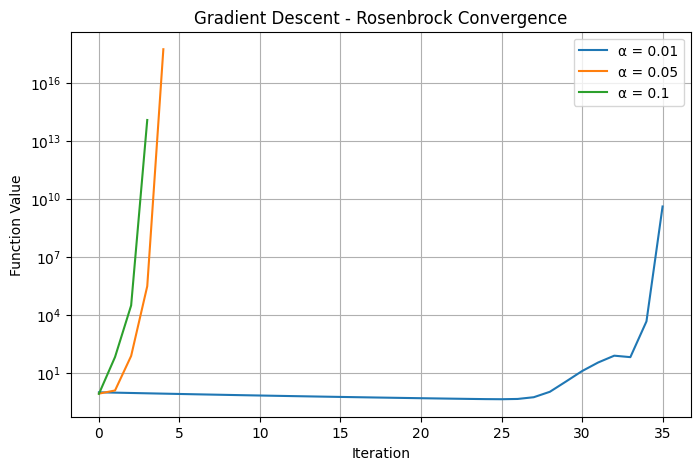

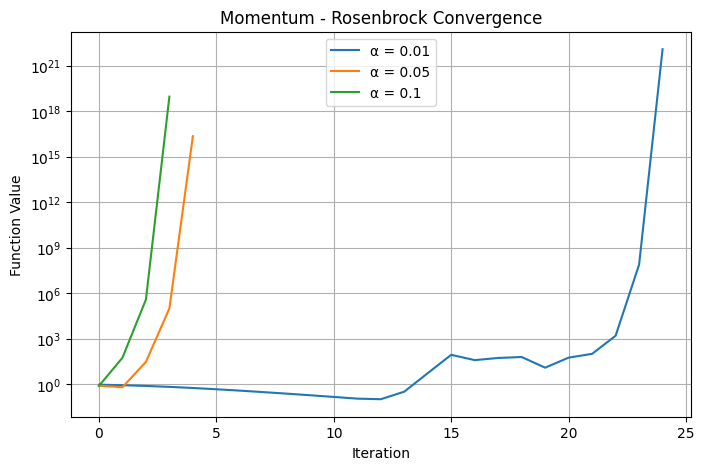

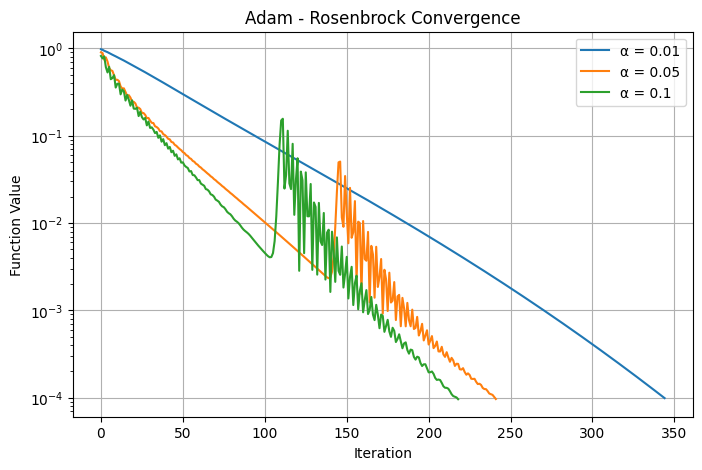

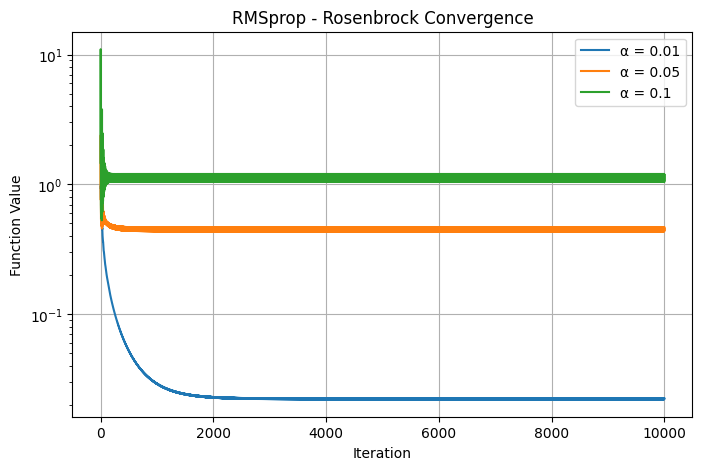

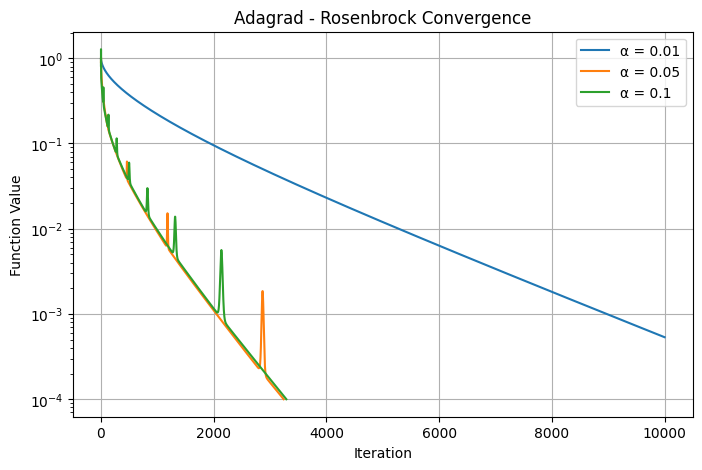

In [25]:
for optimizer_name in optimizers.keys():

    plt.figure(figsize=(8, 5))

    for learning_rate in learning_rates:

        row = rosenbrock_df[
            (rosenbrock_df["Optimizer"] == optimizer_name) &
            (rosenbrock_df["Learning Rate"] == learning_rate)
        ].iloc[0]

        history = row["History"]

        plt.plot(
            history,
            label=f"α = {learning_rate}"
        )

    plt.xlabel("Iteration")
    plt.ylabel("Function Value")
    plt.title(f"{optimizer_name} - Rosenbrock Convergence")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)

    plt.show()

**CONVERGENCE PLOT FOR ACKELEY**

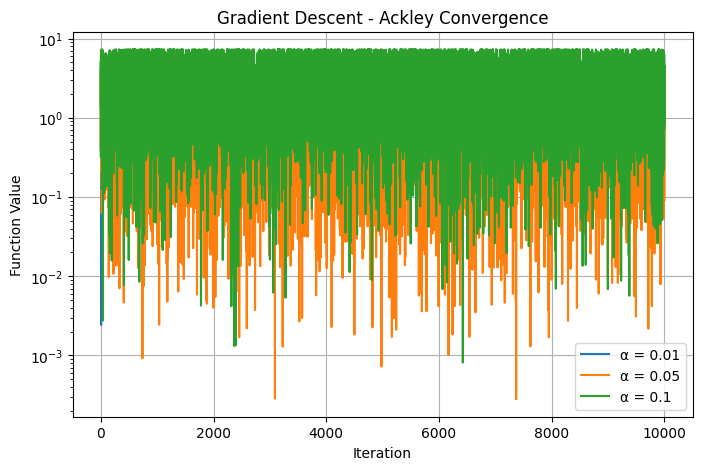

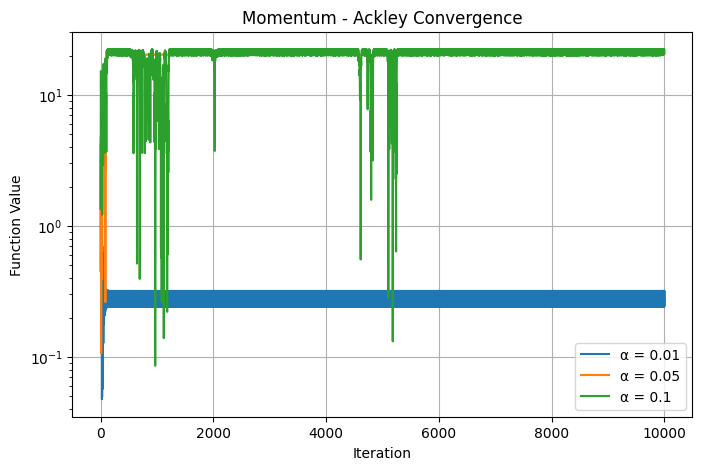

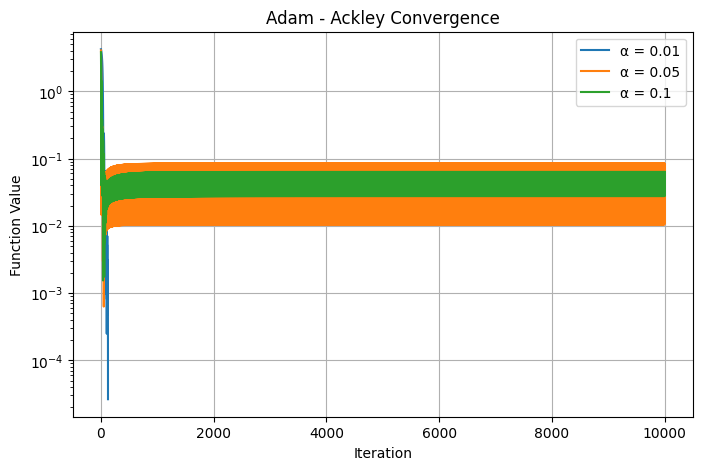

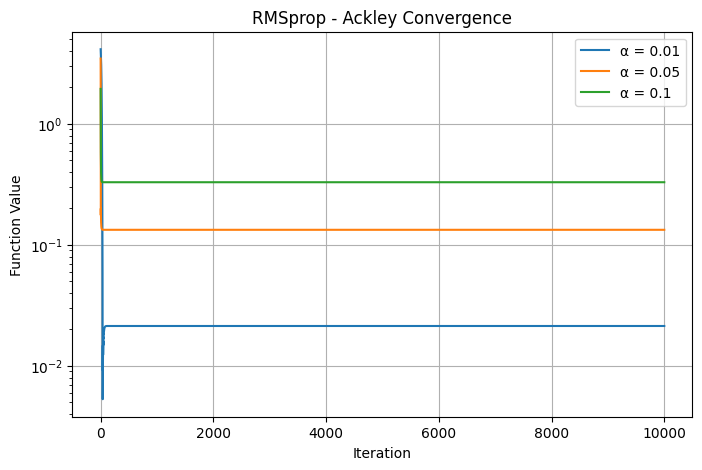

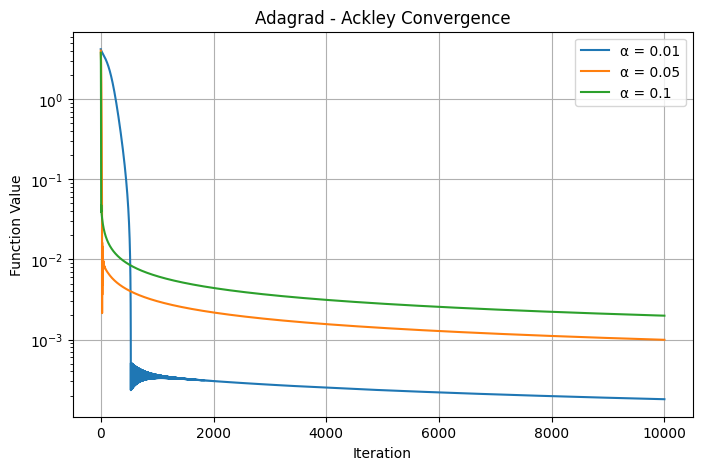

In [26]:
for optimizer_name in optimizers.keys():

    plt.figure(figsize=(8, 5))

    for learning_rate in learning_rates:

        row = ackley_df[
            (ackley_df["Optimizer"] == optimizer_name) &
            (ackley_df["Learning Rate"] == learning_rate)
        ].iloc[0]

        history = row["History"]

        plt.plot(
            history,
            label=f"α = {learning_rate}"
        )

    plt.xlabel("Iteration")
    plt.ylabel("Function Value")
    plt.title(f"{optimizer_name} - Ackley Convergence")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)

    plt.show()

**ROSENBROCK RESULT**

In [27]:
rosenbrock_summary = rosenbrock_df.drop(
    columns=["History"]
).copy()

rosenbrock_summary

,Optimizer,Learning Rate,X,Y,Function Value,Iterations,Time (seconds)
0,Gradient Descent,0.01,-2.035754e+06,1.275467e+04,inf,37,0.004531
1,Gradient Descent,0.05,-1.307335e+13,7.531888e+08,inf,6,0.001747
2,Gradient Descent,0.10,4.655138e+10,2.212626e+07,inf,5,0.000555
3,Momentum,0.01,-1.061628e+05,1.791423e+03,1.270252e+22,25,0.003317
4,Momentum,0.05,3.911006e+03,3.311171e+02,2.339564e+16,5,0.000851
5,Momentum,0.10,-1.754338e+04,1.226111e+03,9.472166e+18,4,0.000605
6,Adam,0.01,9.900659e-01,9.801999e-01,9.877988e-05,345,0.060487
7,Adam,0.05,9.901808e-01,9.804264e-01,9.651686e-05,242,0.036730
8,Adam,0.10,9.905240e-01,9.808894e-01,9.596814e-05,219,0.029854
9,RMSprop,0.01,9.801451e-01,9.755358e-01,2.245074e-02,10000,1.010485


**ACKELEY RESULT**

In [28]:
ackley_summary = ackley_df.drop(
    columns=["History"]
).copy()

In [29]:
ackley_summary["Status"] = np.where(
    np.isfinite(ackley_summary["Function Value"]) &
    (ackley_summary["Function Value"] < 1e-4),
    "Converged",
    "Not Converged"
)

ackley_summary

,Optimizer,Learning Rate,X,Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,-0.040789,0.249844,10000,0.832795,Not Converged
1,Gradient Descent,0.05,-0.174000,1.818901,10000,0.700207,Not Converged
2,Gradient Descent,0.10,-0.087705,0.721785,10000,0.792000,Not Converged
3,Momentum,0.01,-0.048888,0.318899,10000,0.801903,Not Converged
4,Momentum,0.05,20.881553,20.324419,10000,0.740616,Not Converged
5,Momentum,0.10,466.665850,22.114437,10000,0.745674,Not Converged
6,Adam,0.01,-0.000007,0.000026,126,0.007559,Converged
7,Adam,0.05,0.012128,0.056331,10000,0.900855,Not Converged
8,Adam,0.10,0.013394,0.063108,10000,0.989324,Not Converged
9,RMSprop,0.01,-0.005000,0.021331,10000,1.026359,Not Converged


In [30]:
rosenbrock_summary = rosenbrock_summary.round({
    "X": 6,
    "Y": 6,
    "Function Value": 6,
    "Time (seconds)": 6
})

rosenbrock_summary

,Optimizer,Learning Rate,X,Y,Function Value,Iterations,Time (seconds)
0,Gradient Descent,0.01,-2.035754e+06,1.275467e+04,inf,37,0.004531
1,Gradient Descent,0.05,-1.307335e+13,7.531888e+08,inf,6,0.001747
2,Gradient Descent,0.10,4.655138e+10,2.212626e+07,inf,5,0.000555
3,Momentum,0.01,-1.061628e+05,1.791423e+03,1.270252e+22,25,0.003317
4,Momentum,0.05,3.911006e+03,3.311171e+02,2.339564e+16,5,0.000851
5,Momentum,0.10,-1.754338e+04,1.226111e+03,9.472166e+18,4,0.000605
6,Adam,0.01,9.900660e-01,9.802000e-01,9.900000e-05,345,0.060487
7,Adam,0.05,9.901810e-01,9.804260e-01,9.700000e-05,242,0.036730
8,Adam,0.10,9.905240e-01,9.808890e-01,9.600000e-05,219,0.029854
9,RMSprop,0.01,9.801450e-01,9.755360e-01,2.245100e-02,10000,1.010485


In [31]:
ackley_summary = ackley_summary.round({
    "X": 6,
    "Function Value": 6,
    "Time (seconds)": 6
})

ackley_summary

,Optimizer,Learning Rate,X,Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,-0.040789,0.249844,10000,0.832795,Not Converged
1,Gradient Descent,0.05,-0.174000,1.818901,10000,0.700207,Not Converged
2,Gradient Descent,0.10,-0.087705,0.721785,10000,0.792000,Not Converged
3,Momentum,0.01,-0.048888,0.318899,10000,0.801903,Not Converged
4,Momentum,0.05,20.881553,20.324419,10000,0.740616,Not Converged
5,Momentum,0.10,466.665850,22.114437,10000,0.745674,Not Converged
6,Adam,0.01,-0.000007,0.000026,126,0.007559,Converged
7,Adam,0.05,0.012128,0.056331,10000,0.900855,Not Converged
8,Adam,0.10,0.013394,0.063108,10000,0.989324,Not Converged
9,RMSprop,0.01,-0.005000,0.021331,10000,1.026359,Not Converged


**BEST ROSENBROCK RESULT**

In [32]:
best_rosenbrock = rosenbrock_summary.loc[
    rosenbrock_summary["Function Value"].idxmin()
]

best_rosenbrock

,8
Optimizer,Adam
Learning Rate,0.1
X,0.990524
Y,0.980889
Function Value,0.000096
Iterations,219
Time (seconds),0.029854


**BEST ACKELEY RESULT**

In [33]:
best_ackley = ackley_summary.loc[
    ackley_summary["Function Value"].idxmin()
]

best_ackley

,6
Optimizer,Adam
Learning Rate,0.01
X,-0.000007
Function Value,0.000026
Iterations,126
Time (seconds),0.007559
Status,Converged


**FASTEST ROSENBROCK OPTIMIZER**

In [34]:
fastest_rosenbrock = rosenbrock_summary.loc[
    rosenbrock_summary["Time (seconds)"].idxmin()
]

fastest_rosenbrock

,2
Optimizer,Gradient Descent
Learning Rate,0.1
X,46551379301.101982
Y,22126255.635774
Function Value,inf
Iterations,5
Time (seconds),0.000555


**FATEST ACKELEY OPTIMIZER**

In [35]:
fastest_ackley = ackley_summary.loc[
    ackley_summary["Time (seconds)"].idxmin()
]

fastest_ackley

,6
Optimizer,Adam
Learning Rate,0.01
X,-0.000007
Function Value,0.000026
Iterations,126
Time (seconds),0.007559
Status,Converged


**COMPARISON**

In [36]:
rosenbrock_comparison = (
    rosenbrock_summary
    .groupby("Optimizer")
    .agg({
        "Function Value": "mean",
        "Iterations": "mean",
        "Time (seconds)": "mean"
    })
    .sort_values("Function Value")
)

rosenbrock_comparison

,Function Value,Iterations,Time (seconds)
Optimizer,,,
Adam,9.733333e-05,268.666667,0.042357
Adagrad,2.446667e-04,5511.000000,0.339868
RMSprop,5.135253e-01,10000.000000,0.855301
Momentum,4.237339e+21,11.333333,0.001591
Gradient Descent,inf,16.000000,0.002278


In [37]:
ackley_comparison = (
    ackley_summary
    .groupby("Optimizer")
    .agg({
        "Function Value": "mean",
        "Iterations": "mean",
        "Time (seconds)": "mean"
    })
    .sort_values("Function Value")
)

ackley_comparison

,Function Value,Iterations,Time (seconds)
Optimizer,,,
Adagrad,0.001053,10000.000000,1.050096
Adam,0.039822,6708.666667,0.632579
RMSprop,0.161062,10000.000000,1.167063
Gradient Descent,0.930177,10000.000000,0.775001
Momentum,14.252585,10000.000000,0.762731


**COMPARE LEARNING RATES**

In [38]:
rosenbrock_lr_comparison = (
    rosenbrock_summary
    .groupby("Learning Rate")
    .agg({
        "Function Value": "mean",
        "Iterations": "mean",
        "Time (seconds)": "mean"
    })
)

rosenbrock_lr_comparison

,Function Value,Iterations,Time (seconds)
Learning Rate,,,
0.01,inf,4081.4,0.339721
0.05,inf,2699.2,0.214429
0.10,inf,2703.6,0.190686


In [39]:
ackley_lr_comparison = (
    ackley_summary
    .groupby("Learning Rate")
    .agg({
        "Function Value": "mean",
        "Iterations": "mean",
        "Time (seconds)": "mean"
    })
)

ackley_lr_comparison

,Function Value,Iterations,Time (seconds)
Learning Rate,,,
0.01,0.118056,8025.2,0.794420
0.05,4.466731,10000.0,0.920812
0.10,4.646032,10000.0,0.917250


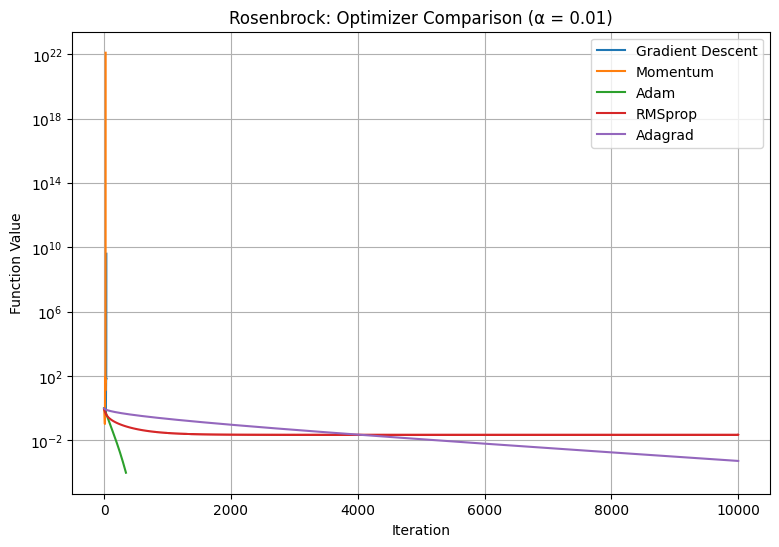

In [40]:
plt.figure(figsize=(9, 6))

for optimizer_name in optimizers.keys():

    row = rosenbrock_df[
        (rosenbrock_df["Optimizer"] == optimizer_name) &
        (rosenbrock_df["Learning Rate"] == 0.01)
    ].iloc[0]

    plt.plot(
        row["History"],
        label=optimizer_name
    )

plt.xlabel("Iteration")
plt.ylabel("Function Value")
plt.title("Rosenbrock: Optimizer Comparison (α = 0.01)")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

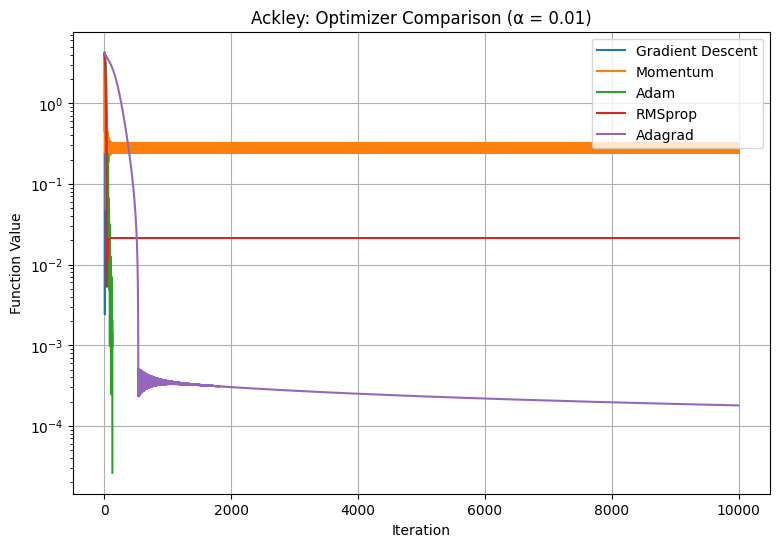

In [41]:
plt.figure(figsize=(9, 6))

for optimizer_name in optimizers.keys():

    row = ackley_df[
        (ackley_df["Optimizer"] == optimizer_name) &
        (ackley_df["Learning Rate"] == 0.01)
    ].iloc[0]

    plt.plot(
        row["History"],
        label=optimizer_name
    )

plt.xlabel("Iteration")
plt.ylabel("Function Value")
plt.title("Ackley: Optimizer Comparison (α = 0.01)")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
rosenbrock_summary

,Optimizer,Learning Rate,X,Y,Function Value,Iterations,Time (seconds)
0,Gradient Descent,0.01,-2.035754e+06,1.275467e+04,inf,37,0.004531
1,Gradient Descent,0.05,-1.307335e+13,7.531888e+08,inf,6,0.001747
2,Gradient Descent,0.10,4.655138e+10,2.212626e+07,inf,5,0.000555
3,Momentum,0.01,-1.061628e+05,1.791423e+03,1.270252e+22,25,0.003317
4,Momentum,0.05,3.911006e+03,3.311171e+02,2.339564e+16,5,0.000851
5,Momentum,0.10,-1.754338e+04,1.226111e+03,9.472166e+18,4,0.000605
6,Adam,0.01,9.900660e-01,9.802000e-01,9.900000e-05,345,0.060487
7,Adam,0.05,9.901810e-01,9.804260e-01,9.700000e-05,242,0.036730
8,Adam,0.10,9.905240e-01,9.808890e-01,9.600000e-05,219,0.029854
9,RMSprop,0.01,9.801450e-01,9.755360e-01,2.245100e-02,10000,1.010485


In [43]:
ackley_summary

,Optimizer,Learning Rate,X,Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,-0.040789,0.249844,10000,0.832795,Not Converged
1,Gradient Descent,0.05,-0.174000,1.818901,10000,0.700207,Not Converged
2,Gradient Descent,0.10,-0.087705,0.721785,10000,0.792000,Not Converged
3,Momentum,0.01,-0.048888,0.318899,10000,0.801903,Not Converged
4,Momentum,0.05,20.881553,20.324419,10000,0.740616,Not Converged
5,Momentum,0.10,466.665850,22.114437,10000,0.745674,Not Converged
6,Adam,0.01,-0.000007,0.000026,126,0.007559,Converged
7,Adam,0.05,0.012128,0.056331,10000,0.900855,Not Converged
8,Adam,0.10,0.013394,0.063108,10000,0.989324,Not Converged
9,RMSprop,0.01,-0.005000,0.021331,10000,1.026359,Not Converged


In [44]:
rosenbrock_summary["Status"] = np.where(
    np.isfinite(rosenbrock_summary["Function Value"]) &
    (rosenbrock_summary["Function Value"] < 1e-4),
    "Converged",
    "Not Converged"
)

rosenbrock_summary

,Optimizer,Learning Rate,X,Y,Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,-2.035754e+06,1.275467e+04,inf,37,0.004531,Not Converged
1,Gradient Descent,0.05,-1.307335e+13,7.531888e+08,inf,6,0.001747,Not Converged
2,Gradient Descent,0.10,4.655138e+10,2.212626e+07,inf,5,0.000555,Not Converged
3,Momentum,0.01,-1.061628e+05,1.791423e+03,1.270252e+22,25,0.003317,Not Converged
4,Momentum,0.05,3.911006e+03,3.311171e+02,2.339564e+16,5,0.000851,Not Converged
5,Momentum,0.10,-1.754338e+04,1.226111e+03,9.472166e+18,4,0.000605,Not Converged
6,Adam,0.01,9.900660e-01,9.802000e-01,9.900000e-05,345,0.060487,Converged
7,Adam,0.05,9.901810e-01,9.804260e-01,9.700000e-05,242,0.036730,Converged
8,Adam,0.10,9.905240e-01,9.808890e-01,9.600000e-05,219,0.029854,Converged
9,RMSprop,0.01,9.801450e-01,9.755360e-01,2.245100e-02,10000,1.010485,Not Converged


In [45]:
rosenbrock_summary["Status"].value_counts()

,count
Status,
Not Converged,12
Converged,3


In [46]:
ackley_summary["Status"].value_counts()

,count
Status,
Not Converged,14
Converged,1


In [47]:
rosenbrock_summary[
    rosenbrock_summary["Status"] == "Converged"
]

,Optimizer,Learning Rate,X,Y,Function Value,Iterations,Time (seconds),Status
6,Adam,0.01,0.990066,0.980200,0.000099,345,0.060487,Converged
7,Adam,0.05,0.990181,0.980426,0.000097,242,0.036730,Converged
8,Adam,0.10,0.990524,0.980889,0.000096,219,0.029854,Converged


In [48]:
rosenbrock_summary[
    rosenbrock_summary["Status"] == "Not Converged"
]

,Optimizer,Learning Rate,X,Y,Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,-2.035754e+06,1.275467e+04,inf,37,0.004531,Not Converged
1,Gradient Descent,0.05,-1.307335e+13,7.531888e+08,inf,6,0.001747,Not Converged
2,Gradient Descent,0.10,4.655138e+10,2.212626e+07,inf,5,0.000555,Not Converged
3,Momentum,0.01,-1.061628e+05,1.791423e+03,1.270252e+22,25,0.003317,Not Converged
4,Momentum,0.05,3.911006e+03,3.311171e+02,2.339564e+16,5,0.000851,Not Converged
5,Momentum,0.10,-1.754338e+04,1.226111e+03,9.472166e+18,4,0.000605,Not Converged
9,RMSprop,0.01,9.801450e-01,9.755360e-01,2.245100e-02,10000,1.010485,Not Converged
10,RMSprop,0.05,6.750000e-01,5.156250e-01,4.656250e-01,10000,0.829641,Not Converged
11,RMSprop,0.10,3.000000e-01,1.500000e-02,1.052500e+00,10000,0.725776,Not Converged
12,Adagrad,0.01,9.768980e-01,9.542990e-01,5.340000e-04,10000,0.619784,Not Converged


In [49]:
ackley_summary[
    ackley_summary["Status"] == "Converged"
]

,Optimizer,Learning Rate,X,Function Value,Iterations,Time (seconds),Status
6,Adam,0.01,-0.000007,0.000026,126,0.007559,Converged


In [50]:
ackley_summary[
    ackley_summary["Status"] == "Not Converged"
]

,Optimizer,Learning Rate,X,Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,-0.040789,0.249844,10000,0.832795,Not Converged
1,Gradient Descent,0.05,-0.174000,1.818901,10000,0.700207,Not Converged
2,Gradient Descent,0.10,-0.087705,0.721785,10000,0.792000,Not Converged
3,Momentum,0.01,-0.048888,0.318899,10000,0.801903,Not Converged
4,Momentum,0.05,20.881553,20.324419,10000,0.740616,Not Converged
5,Momentum,0.10,466.665850,22.114437,10000,0.745674,Not Converged
7,Adam,0.05,0.012128,0.056331,10000,0.900855,Not Converged
8,Adam,0.10,0.013394,0.063108,10000,0.989324,Not Converged
9,RMSprop,0.01,-0.005000,0.021331,10000,1.026359,Not Converged
10,RMSprop,0.05,-0.025000,0.133012,10000,1.133124,Not Converged


In [51]:
best_rosenbrock = (
    rosenbrock_summary[
        rosenbrock_summary["Status"] == "Converged"
    ]
    .sort_values("Function Value")
    .iloc[0]
)

best_rosenbrock

,8
Optimizer,Adam
Learning Rate,0.1
X,0.990524
Y,0.980889
Function Value,0.000096
Iterations,219
Time (seconds),0.029854
Status,Converged


In [52]:
ackley_converged = ackley_summary[
    ackley_summary["Status"] == "Converged"
]

ackley_converged

,Optimizer,Learning Rate,X,Function Value,Iterations,Time (seconds),Status
6,Adam,0.01,-0.000007,0.000026,126,0.007559,Converged


In [53]:
ackley_summary

,Optimizer,Learning Rate,X,Function Value,Iterations,Time (seconds),Status
0,Gradient Descent,0.01,-0.040789,0.249844,10000,0.832795,Not Converged
1,Gradient Descent,0.05,-0.174000,1.818901,10000,0.700207,Not Converged
2,Gradient Descent,0.10,-0.087705,0.721785,10000,0.792000,Not Converged
3,Momentum,0.01,-0.048888,0.318899,10000,0.801903,Not Converged
4,Momentum,0.05,20.881553,20.324419,10000,0.740616,Not Converged
5,Momentum,0.10,466.665850,22.114437,10000,0.745674,Not Converged
6,Adam,0.01,-0.000007,0.000026,126,0.007559,Converged
7,Adam,0.05,0.012128,0.056331,10000,0.900855,Not Converged
8,Adam,0.10,0.013394,0.063108,10000,0.989324,Not Converged
9,RMSprop,0.01,-0.005000,0.021331,10000,1.026359,Not Converged


In [54]:
best_ackley = ackley_summary.loc[
    ackley_summary["Function Value"].idxmin()
]

best_ackley

,6
Optimizer,Adam
Learning Rate,0.01
X,-0.000007
Function Value,0.000026
Iterations,126
Time (seconds),0.007559
Status,Converged


In [55]:
rosenbrock_optimizer_summary = (
    rosenbrock_summary
    .groupby("Optimizer")
    .agg(
        Average_Function_Value=("Function Value", "mean"),
        Average_Iterations=("Iterations", "mean"),
        Average_Time=("Time (seconds)", "mean"),
        Converged_Runs=("Status", lambda x: (x == "Converged").sum())
    )
    .sort_values("Average_Function_Value")
)

rosenbrock_optimizer_summary

,Average_Function_Value,Average_Iterations,Average_Time,Converged_Runs
Optimizer,,,,
Adam,9.733333e-05,268.666667,0.042357,3
Adagrad,2.446667e-04,5511.000000,0.339868,0
RMSprop,5.135253e-01,10000.000000,0.855301,0
Momentum,4.237339e+21,11.333333,0.001591,0
Gradient Descent,inf,16.000000,0.002278,0


In [56]:
ackley_optimizer_summary = (
    ackley_summary
    .groupby("Optimizer")
    .agg(
        Average_Function_Value=("Function Value", "mean"),
        Average_Iterations=("Iterations", "mean"),
        Average_Time=("Time (seconds)", "mean")
    )
    .sort_values("Average_Function_Value")
)

ackley_optimizer_summary

,Average_Function_Value,Average_Iterations,Average_Time
Optimizer,,,
Adagrad,0.001053,10000.000000,1.050096
Adam,0.039822,6708.666667,0.632579
RMSprop,0.161062,10000.000000,1.167063
Gradient Descent,0.930177,10000.000000,0.775001
Momentum,14.252585,10000.000000,0.762731


In [57]:
rosenbrock_learning_rate_summary = (
    rosenbrock_summary
    .groupby("Learning Rate")
    .agg(
        Average_Function_Value=("Function Value", "mean"),
        Average_Iterations=("Iterations", "mean"),
        Average_Time=("Time (seconds)", "mean"),
        Converged_Runs=("Status", lambda x: (x == "Converged").sum())
    )
)

rosenbrock_learning_rate_summary

,Average_Function_Value,Average_Iterations,Average_Time,Converged_Runs
Learning Rate,,,,
0.01,inf,4081.4,0.339721,1
0.05,inf,2699.2,0.214429,1
0.10,inf,2703.6,0.190686,1


In [58]:
ackley_learning_rate_summary = (
    ackley_summary
    .groupby("Learning Rate")
    .agg(
        Average_Function_Value=("Function Value", "mean"),
        Average_Iterations=("Iterations", "mean"),
        Average_Time=("Time (seconds)", "mean")
    )
    .sort_values("Average_Function_Value")
)

ackley_learning_rate_summary

,Average_Function_Value,Average_Iterations,Average_Time
Learning Rate,,,
0.01,0.118056,8025.2,0.794420
0.05,4.466731,10000.0,0.920812
0.10,4.646032,10000.0,0.917250


In [59]:
final_comparison = pd.concat(
    [
        rosenbrock_summary.assign(Function="Rosenbrock"),
        ackley_summary.assign(Function="Ackley")
    ],
    ignore_index=True
)

final_comparison = final_comparison[
    [
        "Function",
        "Optimizer",
        "Learning Rate",
        "Function Value",
        "Iterations",
        "Time (seconds)",
        "Status"
    ]
]

final_comparison

,Function,Optimizer,Learning Rate,Function Value,Iterations,Time (seconds),Status
0,Rosenbrock,Gradient Descent,0.01,inf,37,0.004531,Not Converged
1,Rosenbrock,Gradient Descent,0.05,inf,6,0.001747,Not Converged
2,Rosenbrock,Gradient Descent,0.10,inf,5,0.000555,Not Converged
3,Rosenbrock,Momentum,0.01,1.270252e+22,25,0.003317,Not Converged
4,Rosenbrock,Momentum,0.05,2.339564e+16,5,0.000851,Not Converged
5,Rosenbrock,Momentum,0.10,9.472166e+18,4,0.000605,Not Converged
6,Rosenbrock,Adam,0.01,9.900000e-05,345,0.060487,Converged
7,Rosenbrock,Adam,0.05,9.700000e-05,242,0.036730,Converged
8,Rosenbrock,Adam,0.10,9.600000e-05,219,0.029854,Converged
9,Rosenbrock,RMSprop,0.01,2.245100e-02,10000,1.010485,Not Converged


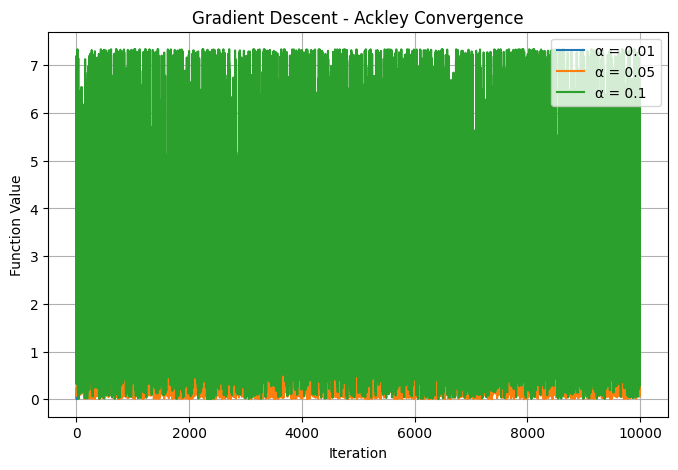

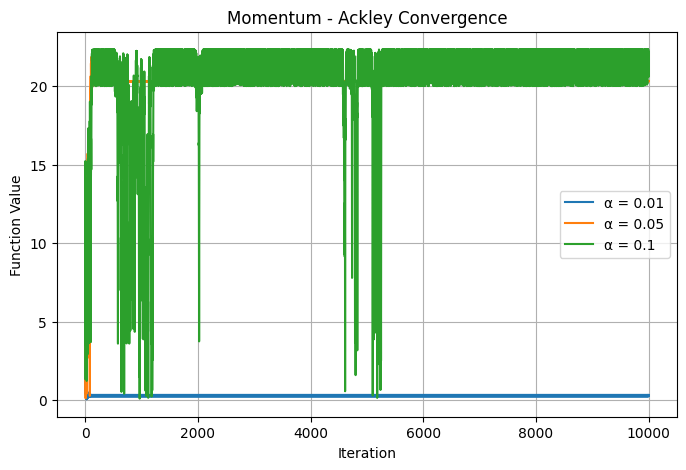

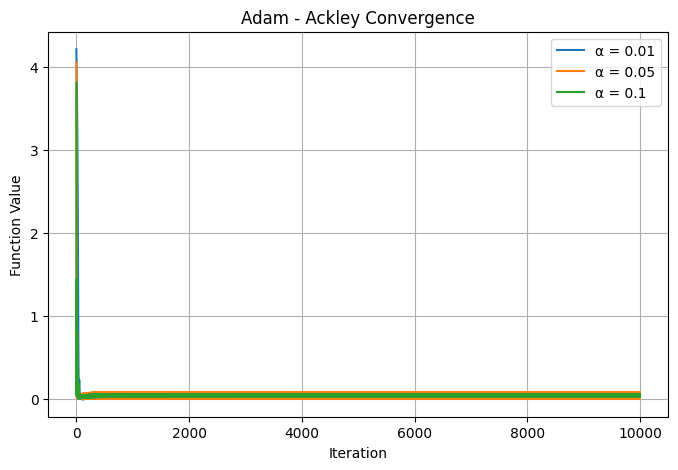

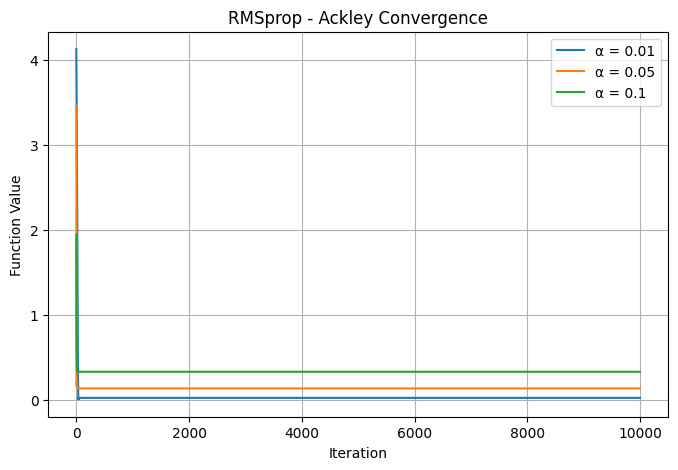

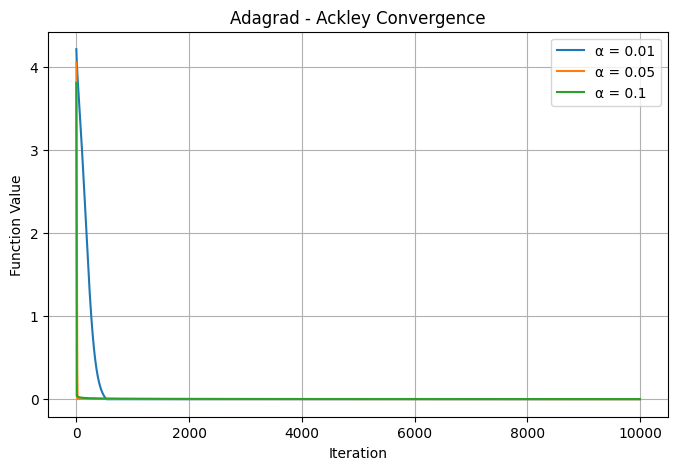

In [60]:
for optimizer_name in optimizers.keys():

    plt.figure(figsize=(8, 5))

    for learning_rate in learning_rates:

        row = ackley_df[
            (ackley_df["Optimizer"] == optimizer_name) &
            (ackley_df["Learning Rate"] == learning_rate)
        ].iloc[0]

        plt.plot(
            row["History"],
            label=f"α = {learning_rate}"
        )

    plt.xlabel("Iteration")
    plt.ylabel("Function Value")
    plt.title(f"{optimizer_name} - Ackley Convergence")
    plt.legend()
    plt.grid(True)

    plt.show()

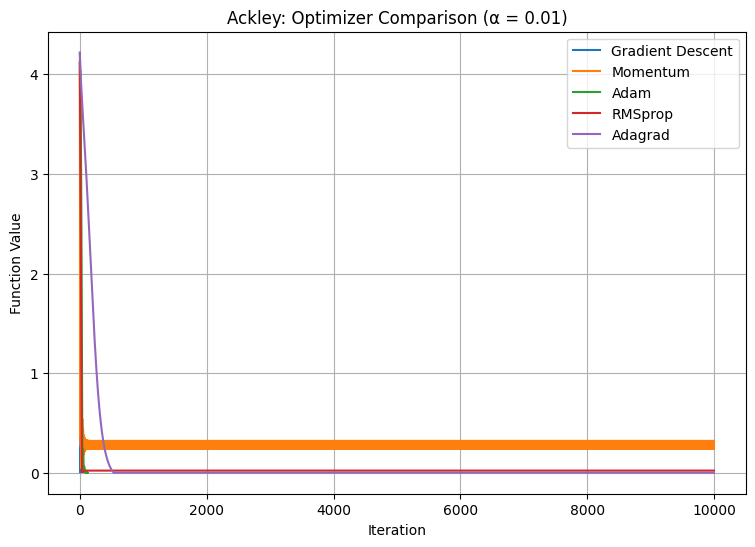

In [61]:
plt.figure(figsize=(9, 6))

for optimizer_name in optimizers.keys():

    row = ackley_df[
        (ackley_df["Optimizer"] == optimizer_name) &
        (ackley_df["Learning Rate"] == 0.01)
    ].iloc[0]

    plt.plot(
        row["History"],
        label=optimizer_name
    )

plt.xlabel("Iteration")
plt.ylabel("Function Value")
plt.title("Ackley: Optimizer Comparison (α = 0.01)")
plt.legend()
plt.grid(True)

plt.show()

In [62]:
best_ackley

,6
Optimizer,Adam
Learning Rate,0.01
X,-0.000007
Function Value,0.000026
Iterations,126
Time (seconds),0.007559
Status,Converged


In [63]:
ackley_optimizer_summary

,Average_Function_Value,Average_Iterations,Average_Time
Optimizer,,,
Adagrad,0.001053,10000.000000,1.050096
Adam,0.039822,6708.666667,0.632579
RMSprop,0.161062,10000.000000,1.167063
Gradient Descent,0.930177,10000.000000,0.775001
Momentum,14.252585,10000.000000,0.762731


In [64]:
ackley_learning_rate_summary

,Average_Function_Value,Average_Iterations,Average_Time
Learning Rate,,,
0.01,0.118056,8025.2,0.794420
0.05,4.466731,10000.0,0.920812
0.10,4.646032,10000.0,0.917250


In [65]:
with pd.ExcelWriter("Task_1_Optimization_Results.xlsx") as writer:

    rosenbrock_summary.to_excel(
        writer,
        sheet_name="Rosenbrock",
        index=False
    )

    ackley_summary.to_excel(
        writer,
        sheet_name="Ackley",
        index=False
    )

    rosenbrock_optimizer_summary.to_excel(
        writer,
        sheet_name="Rosenbrock Optimizers"
    )

    ackley_optimizer_summary.to_excel(
        writer,
        sheet_name="Ackley Optimizers"
    )

    rosenbrock_learning_rate_summary.to_excel(
        writer,
        sheet_name="Rosenbrock LR"
    )

    ackley_learning_rate_summary.to_excel(
        writer,
        sheet_name="Ackley LR"
    )

    final_comparison.to_excel(
        writer,
        sheet_name="Final Comparison",
        index=False
    )

In [66]:
from google.colab import files

files.download("Task_1_Optimization_Results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>